# Trabajo Práctico 3: Redes Neuronales

El objetivo de este trabajo es desarrollar y evaluar modelos basados en redes neuronales,
incorporando técnicas de ablación para entender el impacto de diversas modificaciones en el
proceso de entrenamiento y en la capacidad de generalización del modelo.

## 0. Import modules

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# This enviromental variables change the cpu/threads usage of numpy
import os
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["OPENBLAS_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["VECLIB_MAXIMUM_THREADS"] = "6"
os.environ["NUMEXPR_NUM_THREADS"] = "6"

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import zipfile # for treating zip
sys.path.append('../')

# import modules of project
from src.utils import *
from src.models import *
from src.training_tuning import *

# random state for every lib and mod using np
np.random.seed(42)

# config for future plots and pd visualization
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Análisis y Preprocesamiento de Datos

### a) Examinar el dataset y visualizar al menos 3 imágenes
### b) Dividir el conjunto de datos en tres subconjuntos: Train, Validation y Test.
### c) Normalizar dividiendo todos los valores por 255, de modo que el máximo sea 1.
---

In [4]:
# First thing first, let's open the datasets
with zipfile.ZipFile('../data/datasets.zip', 'r') as z:
    with z.open('I302 ML 2025 2do semestre TP3_ datasets/X_images.npy') as f:
        X_images = np.load(f)
    with z.open('I302 ML 2025 2do semestre TP3_ datasets/y_images.npy') as f:
        y_images = np.load(f)
    with z.open('I302 ML 2025 2do semestre TP3_ datasets/X_COMP.npy') as f:
        X_COMP = np.load(f)


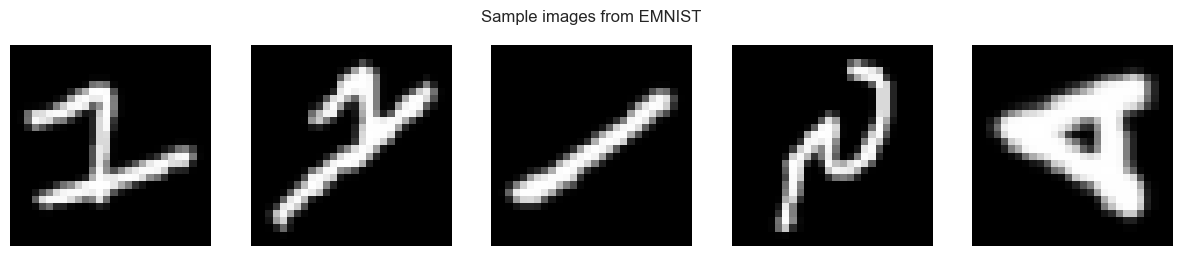

In [5]:
# lets inspect the images
idxs = np.random.choice(len(X_images), size=5, replace=False)
plt.figure(figsize=(15, 3))
plt.title("Sample images from EMNIST")
plt.axis('off')
for i, idx in enumerate(idxs):
    plt.subplot(1, 5, i + 1)
    
    img = X_images[idx].reshape(28, 28)
    
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.show()

In [6]:
print(f"Shape of X_images: {X_images.shape}\nShape of y_images: {y_images.shape}")
num_clases = len(np.unique(y_images))
print(f"Number of classes: {num_clases}")
X_images = X_images.reshape(X_images.shape[0], -1).astype(np.float32)
X_images /= np.float32(255.0)
print(f"Pixel min_value: {X_images.min()}\nPixel max_value: {X_images.max()}")

Shape of X_images: (809555, 28, 28)
Shape of y_images: (809555,)
Number of classes: 47
Pixel min_value: 0.0
Pixel max_value: 1.0


Parece que hay 47 clases de números (y letras dado que trabajamos con Extended MNIST). Esto es algo importante ya que las redes usarán Binary Cross Entropy (BCE) y de alguna forma tiene que estar encodeado numéricamente cada label (más allá del número de clase con el que ya se cuenta). La idea es hacer one hot encoding. Si la complejidad computacional se ve alterada fuertemente por el aumento de la dimensión del dataset, entonces vamos a evaluar otro tipo de encoding.

In [7]:
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X_images,
    y_images,
    train_ratio=0.70,
    val_ratio=0.15
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (566667, 784) (566667,)
Validation: (121410, 784) (121410,)
Test: (121478, 784) (121478,)


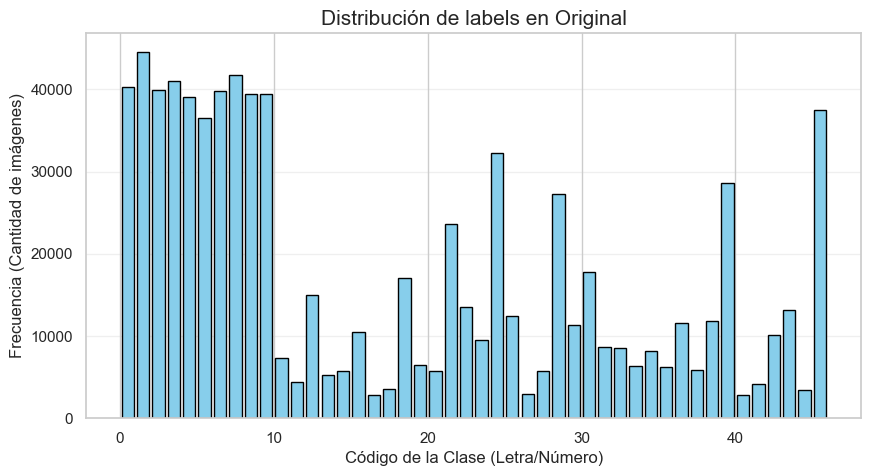

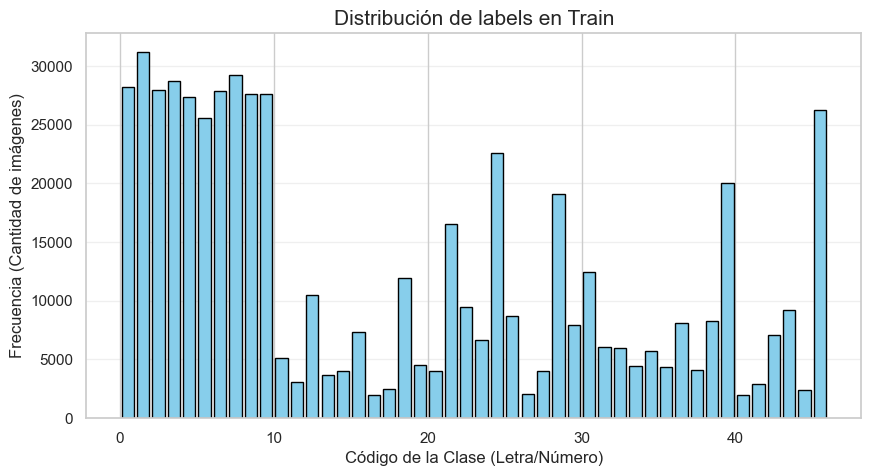

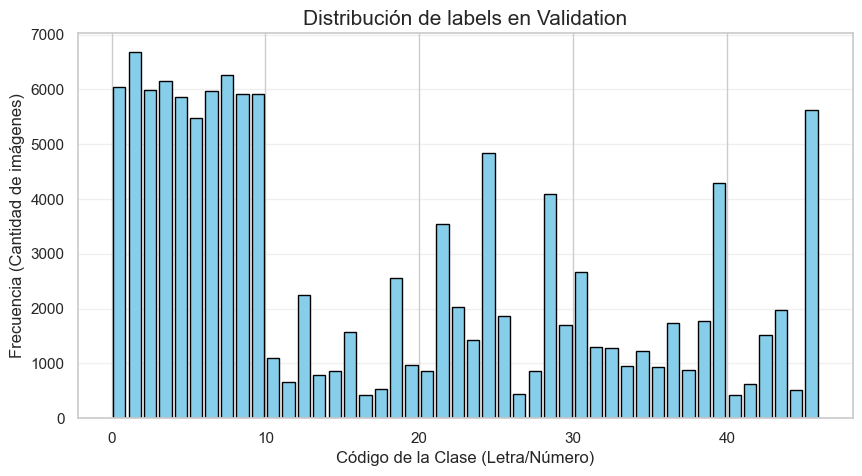

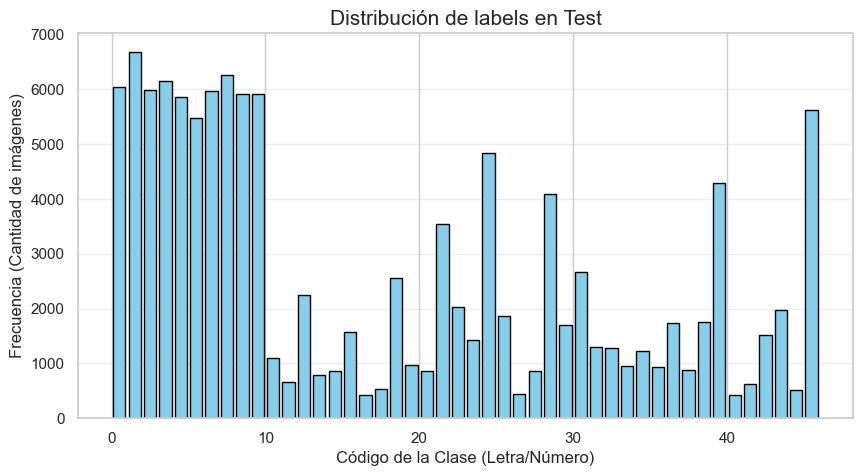

In [8]:
show_label_distribution(y_images, "Original")
show_label_distribution(y_train, "Train")
show_label_distribution(y_val, "Validation")
show_label_distribution(y_test, "Test")

Lo que nos muestran los gráficos, la distribución de las categorías del target se mantiene, por lo cual garantizamos una estratificación representativa para el entrenamiento, validación y testeo.

In [9]:
X_train_flat = flatten_images(X_train)
X_val_flat = flatten_images(X_val)
X_test_flat = flatten_images(X_test)

assert X_train_flat.shape[1] == 784
assert X_val_flat.shape[1] == 784
assert X_test_flat.shape[1] == 784

In [10]:
num_classes = len(np.unique(y_images))
train_size = X_train_flat.shape[0]

y_train_one_hot = one_hot_encode(y_train, num_classes)
y_val_one_hot = one_hot_encode(y_val, num_classes)
y_test_one_hot = one_hot_encode(y_test, num_classes)

Finalmente, flateamos y encodeamos el target para poder usar en la CE

## 2. Implementación y Entrenamiento de una Red Neuronal Básica

### a) Implementar una red neuronal Multi-layer perceptron (MLP) con $L$ capas ocultas, cada una con $M(l)$ nodos, utilizando ReLU en las capas ocultas y activación softmax en la capa de salida.
### b) Implementar un algoritmo para entrenar dicha red, mediante backpropagation y gradiente descendente estándar, utilizando como función de costo la cross-entropy. NOTA: El algoritmo backpropagation debe adaptarse al caso de clasificación multiclase con función de activación softmax en la salida y función de costo cross-entropy.
### c) Entrenar una red neuronal con $2$ capas ocultas, con $128$ y $64$ nodos respectivamente, y graficar la evolución de la función de costo (cross-entropy) sobre los conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a este modelo M0.
### d) Reportar las siguientes métricas de performance, sobre los conjuntos de entrenamiento y validación, para el modelo base entrenado: Accuracy, Cross-Entropy, Matriz de Confusión, F1-Score Macro
---

Epoch 000 | LR: 0.001000 | Train CE: 4.0774 | Val CE: 4.0770
Epoch 010 | LR: 0.001000 | Train CE: 4.0562 | Val CE: 4.0558
Epoch 020 | LR: 0.001000 | Train CE: 4.0366 | Val CE: 4.0361
Epoch 030 | LR: 0.001000 | Train CE: 4.0183 | Val CE: 4.0178
Epoch 040 | LR: 0.001000 | Train CE: 4.0012 | Val CE: 4.0007


Model                     M0
Implementation    Base model
Time [sec]        568.508082
Train CE            3.986833
Val CE              3.986245
Train Accuracy      0.042572
Val Accuracy        0.043851
Train F1 Macro      0.015588
Val F1 Macro         0.01587
dtype: object

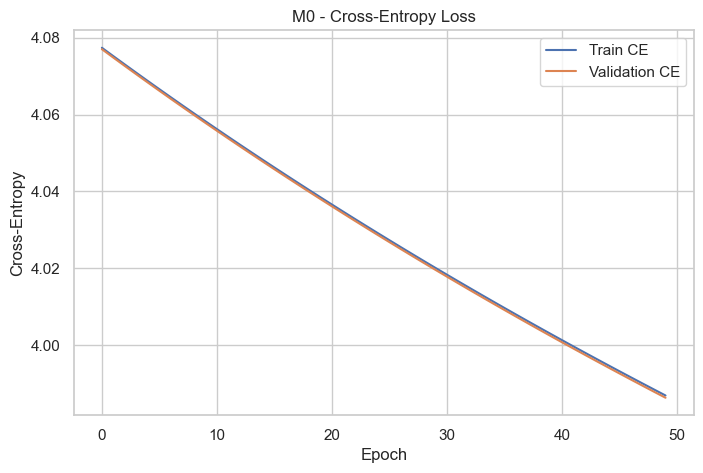

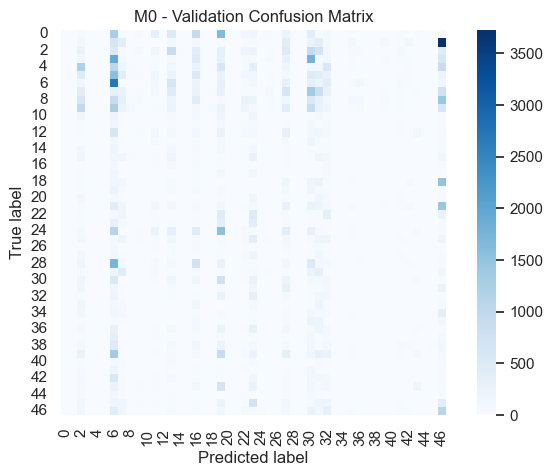

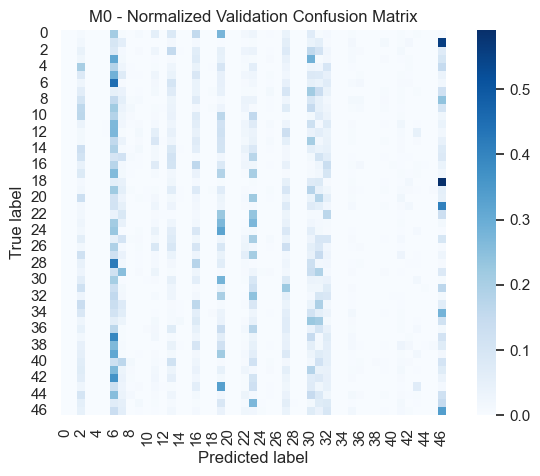

In [12]:
M0 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_M0, history_M0 = train_and_evaluate_model(
    model_name="M0",
    implementation="Base model",
    model=M0,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    plot=True,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada
### a) Implementar las siguientes mejoras al algoritmo de entrenamiento, y para cada una reportar el efecto observado sobre el tiempo de entrenamiento y la performance del modelo resultante.
- Rate scheduling lineal (con saturación) y exponencial.
- Mini-batch stochastic gradient descent.
- Optimizador Adam.
- Regularización (L2, Early Stopping)
- Opcional: Batch normalization.
- Opcional: Label smoothing.
- Opcional: Gradient clipping.
---

### A1 — Mini-batch SGD

In [14]:
a1 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a1, history_a1 = train_and_evaluate_model(
    model_name="A1",
    implementation="Mini-batch SGD",
    model=a1,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": 128,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

Epoch 000 | LR: 0.001000 | Train CE: 2.2237 | Val CE: 2.2222
Epoch 010 | LR: 0.001000 | Train CE: 0.9293 | Val CE: 0.9313
Epoch 020 | LR: 0.001000 | Train CE: 0.7633 | Val CE: 0.7685
Epoch 030 | LR: 0.001000 | Train CE: 0.6732 | Val CE: 0.6802
Epoch 040 | LR: 0.001000 | Train CE: 0.6162 | Val CE: 0.6246


### A2 — Adam

In [ ]:
a2 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a2, history_a2 = train_and_evaluate_model(
    model_name="A2",
    implementation="Adam",
    model=a2,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "adam",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

### A3 — L2 + early stopping

In [ ]:
a3 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a3, history_a3 = train_and_evaluate_model(
    model_name="A3",
    implementation="L2 + early stopping",
    model=a3,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 1e-4,
        "early_stopping": True,
        "verbose": True
    }
)

Epoch 000 | LR: 0.100000 | Train CE: 3.9078 | Val CE: 3.9077
Epoch 010 | LR: 0.100000 | Train CE: 3.2963 | Val CE: 3.2951
Epoch 020 | LR: 0.100000 | Train CE: 2.8008 | Val CE: 2.7986
Epoch 030 | LR: 0.100000 | Train CE: 2.4869 | Val CE: 2.4839
Epoch 040 | LR: 0.100000 | Train CE: 2.2621 | Val CE: 2.2586


### A4 — Exponential LR Scheduler

In [ ]:
a4 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a4, history_a4 = train_and_evaluate_model(
    model_name="A4",
    implementation="Exponential LR Scheduler",
    model=a4,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": "exponential",
        "initial_lr": 0.001,
        "final_lr": 1e-5,
        "decay_rate": 0.97,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

Epoch 000 | LR: 0.100000 | Train CE: 3.8964 | Val CE: 3.8966
Epoch 010 | LR: 0.073742 | Train CE: 3.5410 | Val CE: 3.5404
Epoch 020 | LR: 0.054379 | Train CE: 3.2895 | Val CE: 3.2888
Epoch 030 | LR: 0.040101 | Train CE: 3.0851 | Val CE: 3.0844
Epoch 040 | LR: 0.029571 | Train CE: 2.9404 | Val CE: 2.9398


### A5 — Batch Normalization

In [ ]:
a5 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes],
    use_batch_norm=True
)

result_a5, history_a5 = train_and_evaluate_model(
    model_name="A5",
    implementation="Batch Normalization",
    model=a5,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

Epoch 000 | LR: 0.100000 | Train CE: 3.8908 | Val CE: 3.8912
Epoch 010 | LR: 0.100000 | Train CE: 3.0739 | Val CE: 3.0740
Epoch 020 | LR: 0.100000 | Train CE: 2.4948 | Val CE: 2.4940
Epoch 030 | LR: 0.100000 | Train CE: 2.1503 | Val CE: 2.1487
Epoch 040 | LR: 0.100000 | Train CE: 1.9517 | Val CE: 1.9499


### A6 — Label Smoothing

In [ ]:
a6 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a6, history_a6 = train_and_evaluate_model(
    model_name="A6",
    implementation="Label Smoothing",
    model=a6,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "label_smoothing": 0.05,
        "verbose": True
    }
)

Epoch 000 | LR: 0.100000 | Train CE: 3.8573 | Val CE: 3.8573
Epoch 010 | LR: 0.100000 | Train CE: 3.3193 | Val CE: 3.3192
Epoch 020 | LR: 0.100000 | Train CE: 2.9037 | Val CE: 2.9035
Epoch 030 | LR: 0.100000 | Train CE: 2.5898 | Val CE: 2.5894
Epoch 040 | LR: 0.100000 | Train CE: 2.3517 | Val CE: 2.3508


### A7 — Gradient Clipping

In [ ]:
a7 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a7, history_a7 = train_and_evaluate_model(
    model_name="A7",
    implementation="Gradient Clipping",
    model=a7,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "gradient_clip_norm": 5.0,
        "verbose": True
    }
)

Epoch 000 | LR: 0.100000 | Train CE: 3.9138 | Val CE: 3.9144
Epoch 010 | LR: 0.100000 | Train CE: 3.4752 | Val CE: 3.4752
Epoch 020 | LR: 0.100000 | Train CE: 3.0697 | Val CE: 3.0687
Epoch 030 | LR: 0.100000 | Train CE: 2.7026 | Val CE: 2.7013
Epoch 040 | LR: 0.100000 | Train CE: 2.4347 | Val CE: 2.4334


In [ ]:
ablation_table = pd.DataFrame([
    result_M0,
    result_a1,
    result_a2,
    result_a3,
    result_a4,
    result_a5,
    result_a6,
    result_a7
])
ablation_table.to_csv("../results/tables/results_ablation.csv", index=False)
ablation_table

,Model,Implementation,Time [sec],Train CE,Val CE,Train Accuracy,Val Accuracy,Train F1 Macro,Val F1 Macro
0,M0,Base model,383.284742,2.235324,2.232872,0.475660,0.476831,0.185276,0.186026
1,A1,Mini-batch SGD,402.784647,0.274277,0.369954,0.897158,0.875323,0.875284,0.840757
2,A2,Adam,371.138486,3.080236,3.078381,0.142581,0.142863,0.029962,0.029957
3,A3,L2,364.118880,2.100503,2.096779,0.488539,0.487686,0.209742,0.208780
4,A4,Exponential LR Scheduler,363.544635,2.850303,2.849668,0.379851,0.379689,0.133058,0.132966
5,A5,Batch Normalization,1195.864048,1.830630,1.828565,0.563776,0.564937,0.318489,0.319306
6,A6,Label Smoothing,388.841145,2.185176,2.183768,0.487766,0.486706,0.220282,0.218836
7,A7,Gradient Clipping,377.633651,2.242586,2.241244,0.446414,0.446553,0.175127,0.175091


### b) Explorar cambios en la arquitectura de la red (es decir, la cantidad de capas ocultas y unidades ocultas por capa), y en los hiperparámetros (cada uno de los ítems en la lista anterior tiene parámetros que se pueden variar), y determinar la configuración que funcione mejor (menor error de validación). Llamaremos a este modelo M1.
---

Sobre múltiples combinaciones de hiperparámetros lo estadísticamente correcto sería hacer cross validation. Por ello, se realizó una búsqueda de hiperparámetros mediante K-Fold estratificado sobre el conjunto de desarrollo, construido a partir de train y validation. Los folds se generaron preservando la distribución de clases. La selección de M1 se hizo minimizando la cross-entropy promedio de validación entre folds. El conjunto de test se mantuvo aislado para la comparación final de modelos.

In [ ]:
X_dev = np.concatenate([X_train_flat, X_val_flat], axis=0)
y_dev_one_hot = np.concatenate([y_train_one_hot, y_val_one_hot], axis=0)
X_dev = X_dev.astype(np.float32, copy=False)
y_dev_one_hot = y_dev_one_hot.astype(np.float32, copy=False)
model_grid = {
    "layer_sizes": [
        [784, 128, 64, num_classes],
        [784, 256, 128, num_classes],
    ],
    "use_batch_norm": [False],
}
fit_grid = {
    "epochs": [40],
    "batch_size": [128, 256],
    "optimizer": ["adam"],

    "scheduler": [None],
    "initial_lr": [1e-3],

    "final_lr": [1e-5],
    "decay_rate": [0.97],

    "l2_lambda": [0.0, 1e-4],
    "early_stopping": [True],
    "patience": [5],

    "label_smoothing": [0],
    "gradient_clip_norm": [None],
    "verbose": [False],
}
grid_configs = build_grid_configs(model_grid, fit_grid)
grid_results = grid_search_cv_mlp(
    X=X_dev,
    y_one_hot=y_dev_one_hot,
    model_cls=MLPClassifier,
    grid_configs=grid_configs,
    k_folds=3
)
grid_results["summary"]

In [ ]:
best_model_kwargs = grid_results["best_model_kwargs"]
best_fit_kwargs = grid_results["best_fit_kwargs"]

print("Best model kwargs:")
print(best_model_kwargs)

print("\nBest fit kwargs:")
print(best_fit_kwargs)

print("\nBest mean validation CE:")
print(grid_results["best_score"])
grid_results.to_csv("../results/tables/results_gsearch.csv", index=False)

## 4. Desarrollo de una Red Neuronal con PyTorch
### a) Utilizando PyTorch, entrenar una red neuronal con la arquitectura y los hiperparámetros hallados en el ejercicio anterior. Llamaremos a este modelo M2. Comparar la performance del modelo M1 y M2 para validar que los comportamientos de los modelos son parecidos.
---

In [ ]:
M1 = MLPClassifier(**best_model_kwargs)

start_time = time.perf_counter()
result_M1, history_M1 = train_and_evaluate_model(
    model_name="M1",
    implementation="Best G-search Tuning",
    model=M1,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    plot=True,
    train_config=best_fit_kwargs
)

M1_time = time.perf_counter() - start_time

print(f"M1 training time: {M1_time:.2f} seconds")

### b) Utilizando PyTorch, explorar cambios en la cantidad de capas ocultas y unidades ocultas por capa, y determinar la configuración que funcione mejor. Además de la arquitectura, se deberá experimentar con funciones de activación más modernas disponibles en torch.nn, tales como LeakyReLU, SiLU, Swish o GELU y estrategias de regularizacion adicionales como Dropout (ademas de las ya mencionadas previamente). Llamaremos a este modelo M3.
---

### c) Comparar la performance sobre el conjunto de test de los siguientes cuatro modelos:
1) El modelo base de implementación propia (M0).
2) La mejor arquitectura obtenida con la implementación propia (M1).
3) Modelo en PyTorch, usando la misma arquitectura e hiperparámetros que en la implementación propia (M2).
4) La mejor arquitectura obtenida en PyTorch (M3).
---

### d) Con los modelos ya entrenados, perturbar los datos de test con distintos niveles de ruido y evaluar cuan robusta es la performance de cada modelo frente a estos datos perturbados en comparacion a los resultados obtenidos de datos sin perturbar.
---